In [1]:
from pathlib import Path
from typing import Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import edgepython as ep
import gseapy as gp
from XvP_utils import plotting
import re

%matplotlib inline

# (label, analysis_name, 10x_assay, parse_assay, tissue)
SAMPLES = [
    ("Exp 2a", "Analysis_3", "10x_H1",  "parse_H1"),
    ("Exp 2b", "Analysis_3", "10x_H2",  "parse_H2"),
    ("Exp 3",  "Analysis_5", "10x",      "parse"),
    ("Exp 4",  "Analysis_7", "10x",      "parse"),
]

COMPARING = {"10x": "10X", "polyT": "Parse 3'"}
TECH1, TECH2 = COMPARING.values()
FDR=0.01
PROJECT_DIR = Path("/home/mcaskey/10XvParse/")
SPECIES = "human"
INDEX_DIR = PROJECT_DIR / "Index" / SPECIES

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
combined = plotting.load_cross_comparison_data(SAMPLES, comparison=COMPARING, project_dir=PROJECT_DIR)

Loading Exp 2a...
Loading Exp 2b...
Loading Exp 3...
Loading Exp 4...

28037 genes retained across all 10 samples


TMM norm factors: [0.8756 0.8965 0.8834 0.8596 1.1005 1.1231 1.24   1.0945]
Design: 8 samples x 4 coefficients  (df.residual = 4)
Retained 25006 / 28037 genes after filterByExpr
Common dispersion (BCV): 0.3553


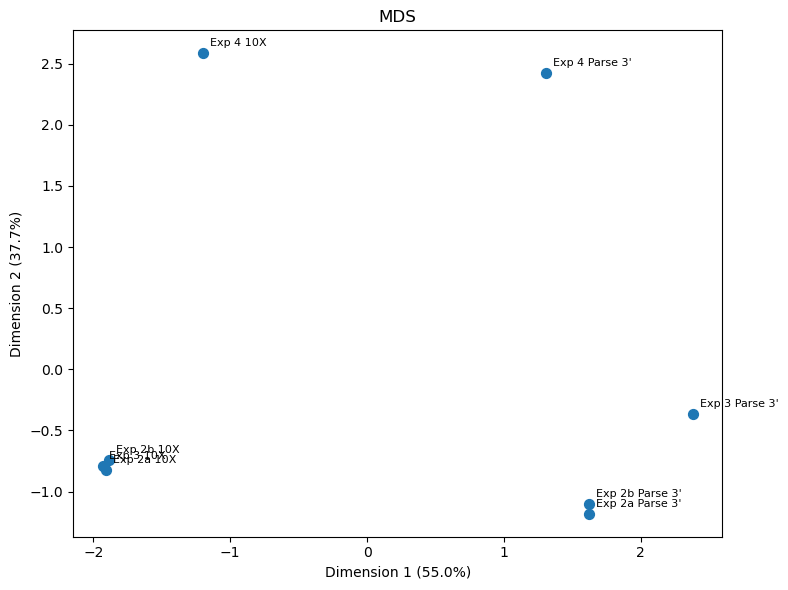

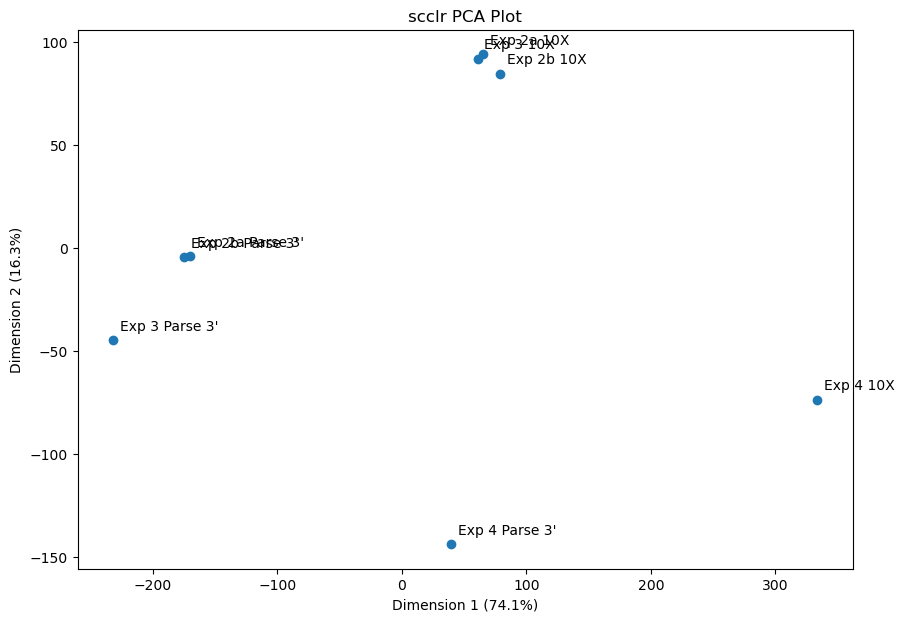

In [4]:
dge_f, fit, qlf, design, results = plotting.perform_edgepy(combined, COMPARING, SAMPLES)

labels      = [s[0] for s in SAMPLES]
col_labels  = [f"{l} {TECH1}" for l in labels] + [f"{l} {TECH2}" for l in labels]

# MDS plot
ep.plot_mds(dge_f, labels=col_labels, main="MDS")
plt.show()

# scclr PCA plot
plotting.scclr_pca(combined, labels=col_labels, comparing=COMPARING)

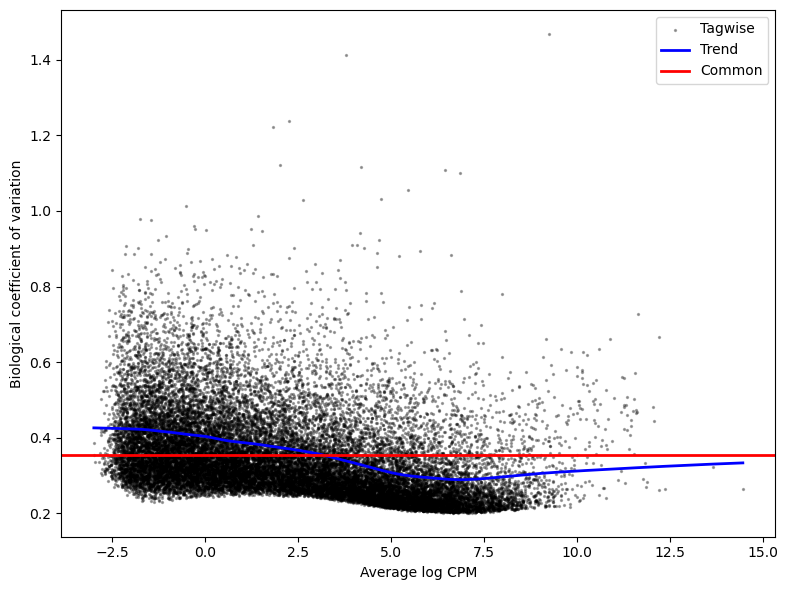

In [5]:
ep.plot_bcv(dge_f, main="BCV plot")
plt.show()

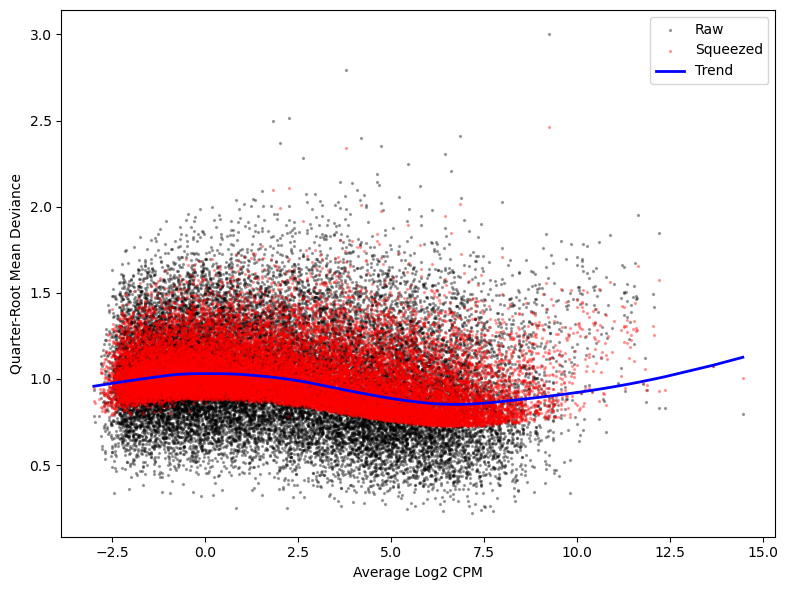

In [6]:
ep.plot_ql_disp(fit, main="QL dispersion")
plt.show()

In [5]:
# Merge gene annotations
attrs = pd.read_csv(
    PROJECT_DIR / "Notebooks/gene_info" / SPECIES / "gene_attributes.csv",
    usecols=["gene_name", "gene_length", "gc_content",
             "is_lnc", "is_pc", "is_mito", "is_ribo", "is_oxphos", "is_pseudo"],
)
results = results.merge(attrs, on="gene_name", how="left")

plotting.annotate_gene_set(
    results,
    PROJECT_DIR / "Notebooks/important_gene_sets.csv",
    "Transcription Factors",
    "is_tf",
    term="Human",
)

# Print number of signifant genes for eachs side
n1   = ((results["FDR"] < FDR) & (results["logFC"] < 0)).sum()
n2 = ((results["FDR"] < FDR) & (results["logFC"] > 0)).sum()
print(f"FDR < {FDR}:  {n1} genes higher in {TECH1},  {n2} genes higher in {TECH2}")

annotate_gene_set: 1197/1639 "Transcription Factors" / "Human" genes matched → 'is_tf'
FDR < 0.01:  5037 genes higher in 10X,  3371 genes higher in Parse 3'


/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:250: UserWarning: annotate_gene_set: 442 genes in "Transcription Factors" / "Human" but missing from gene_info:
  ['AC008770.3', 'AC023509.3', 'AC092835.1', 'AC138696.1', 'AHRR', 'ALX1', 'ALX3', 'ANHX', 'ARGFX', 'ARID3C', 'ARNTL', 'ARNTL2', 'ARX', 'ASCL1', 'ASCL3', 'ASCL4', 'ASCL5', 'ATOH1', 'ATOH7', 'BARHL1', 'BARHL2', 'BARX1', 'BARX2', 'BCL6B', 'BHLHA15', 'BHLHA9', 'BHLHE22', 'BHLHE23', 'BNC1', 'BORCS8-MEF2B', 'BSX', 'C11ORF95', 'CBX2', 'CCDC169-SOHLH2', 'CDX1', 'CDX2', 'CDX4', 'CENPBD1', 'CPXCR1', 'CREB3L1', 'CREB3L3', 'CRX', 'CSRNP3', 'CTCFL', 'DBX1', 'DBX2', 'DLX1', 'DLX2', 'DLX3', 'DLX4', 'DLX5', 'DLX6', 'DMBX1', 'DMRT1', 'DMRT2', 'DMRT3', 'DMRTA1', 'DMRTA2', 'DMRTB1', 'DMRTC2', 'DPRX', 'DRGX', 'DUX1', 'DUX3', 'DUX4', 'DUXA', 'ELF5', 'EMX1', 'EMX2', 'EN1', 'EN2', 'ESX1', 'ETV4', 'EVX1', 'EVX2', 'FAM170A', 'FERD3L', 'FEV', 'FEZF1', 'FEZF2', 'FIGLA', 'FOXA1', 'FOXA2', 'FOXA3', 'FOXB2', 'FOXC2', 'FOXD1', 'FOXD3', 'FOXD4', 'FOX

In [6]:
(results["logFC"] < 0).sum() / len(results), (results["logFC"] > 0).sum() / len(results)

(0.5152363432776134, 0.48476365672238664)

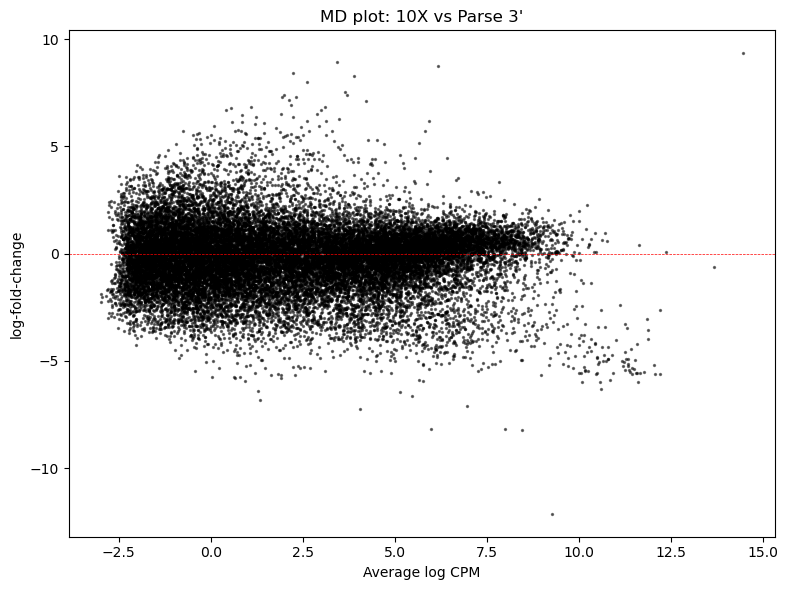

In [8]:
# MD plot
ep.plot_md(qlf, main=f"MD plot: {TECH1} vs {TECH2}")
plt.show()

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:250: UserWarning: volcano_plot: 4 genes in "PBMC Markers" but missing from results:
  ['HBB', 'IL3RA', 'PF4', 'SDC1']
  warnings.warn(


Annotated marker genes (logFC = Parse 3' / 10X):
  PBMC Markers — 50 annotated genes labeled on plot (p=4.98e-07):
     logFC > 0, higher in Parse 3': 7/50 (14.0%)
     logFC < 0, higher in 10X: 43/50 (86.0%)
     significant (FDR < 0.01) higher in Parse 3': 0/50 (0.0%)
     significant (FDR < 0.01) higher in 10X: 29/50 (58.0%)


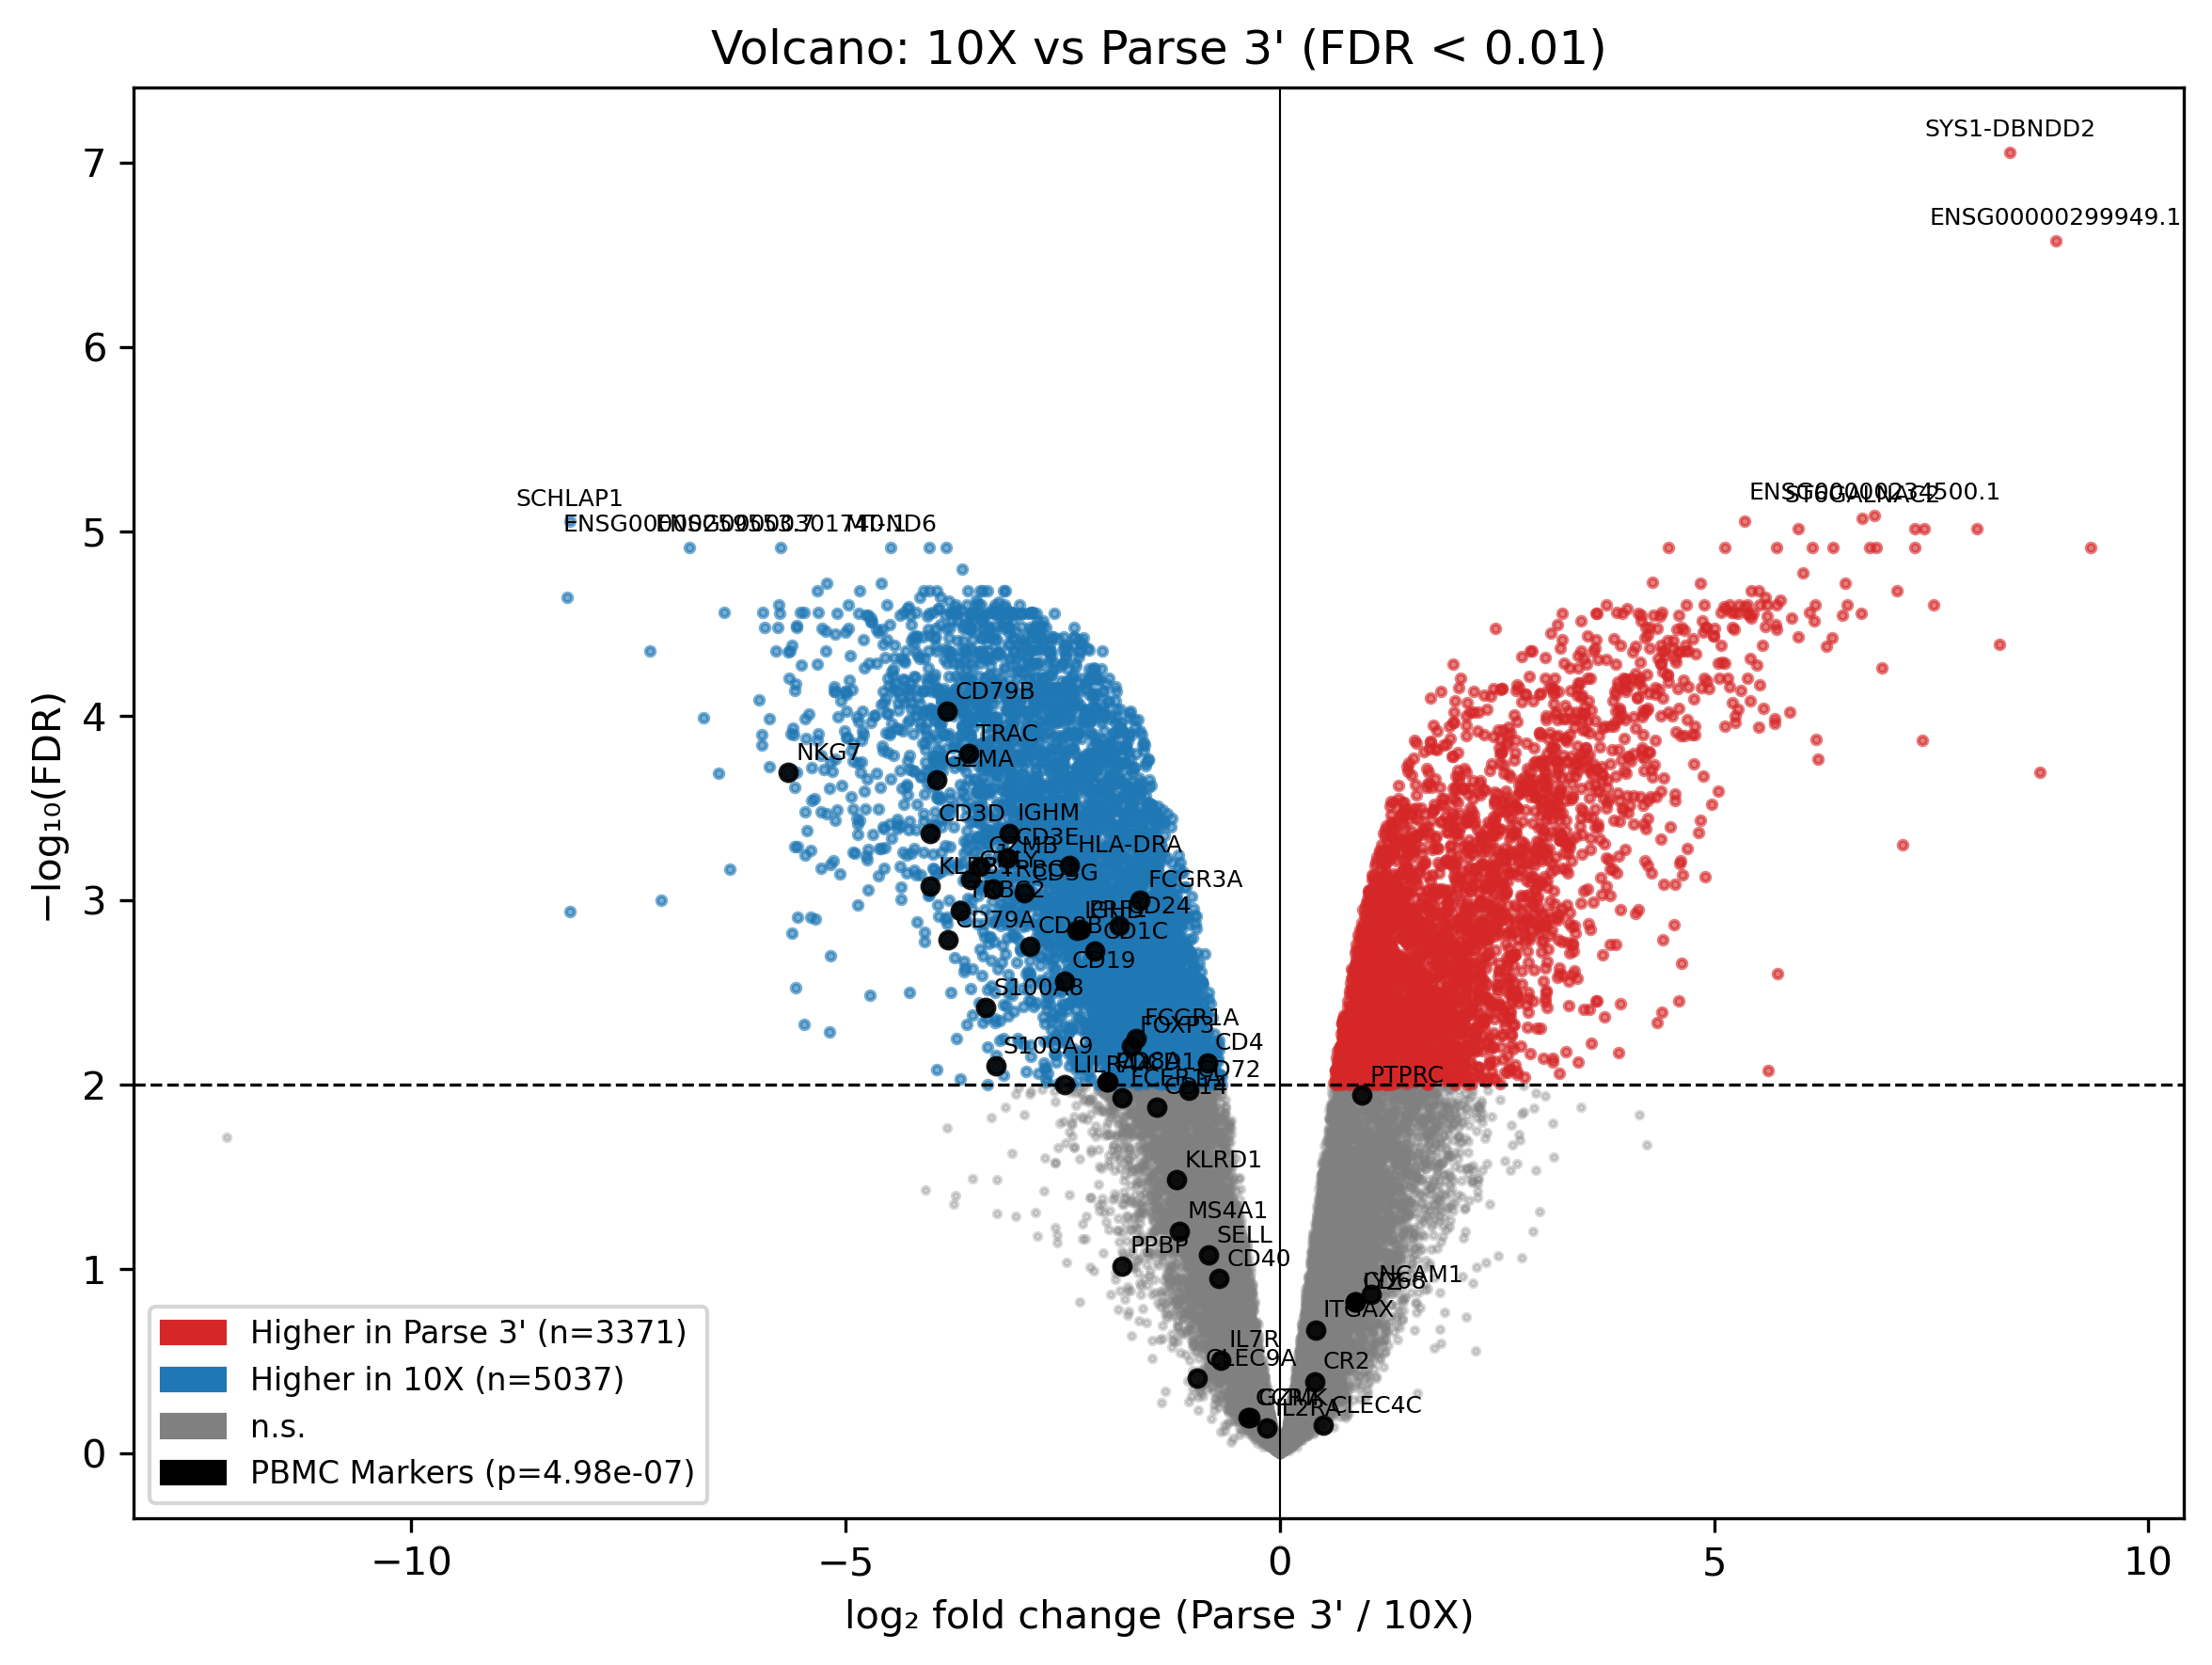

In [9]:
plotting.volcano_plot(results, 
                      COMPARING, 
                      FDR, 
                      label_num = 4,
                      marker_genes_path="/home/mcaskey/10XvParse/Notebooks/important_gene_sets.csv",
                      gene_sets=["Tissue Marker"],
                      terms=["PBMC Markers"],
                      )

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:250: UserWarning: volcano_plot: 1 genes in "Human Housekeeping Genes" but missing from results:
  ['WDR83OS']
  warnings.warn(


Annotated marker genes (logFC = Parse 3' / 10X):
  Human Housekeeping Genes — 1128 annotated genes labeled on plot (p=5.97e-25):
     logFC > 0, higher in Parse 3': 379/1128 (33.6%)
     logFC < 0, higher in 10X: 749/1128 (66.4%)
     significant (FDR < 0.01) higher in Parse 3': 90/1128 (8.0%)
     significant (FDR < 0.01) higher in 10X: 412/1128 (36.5%)


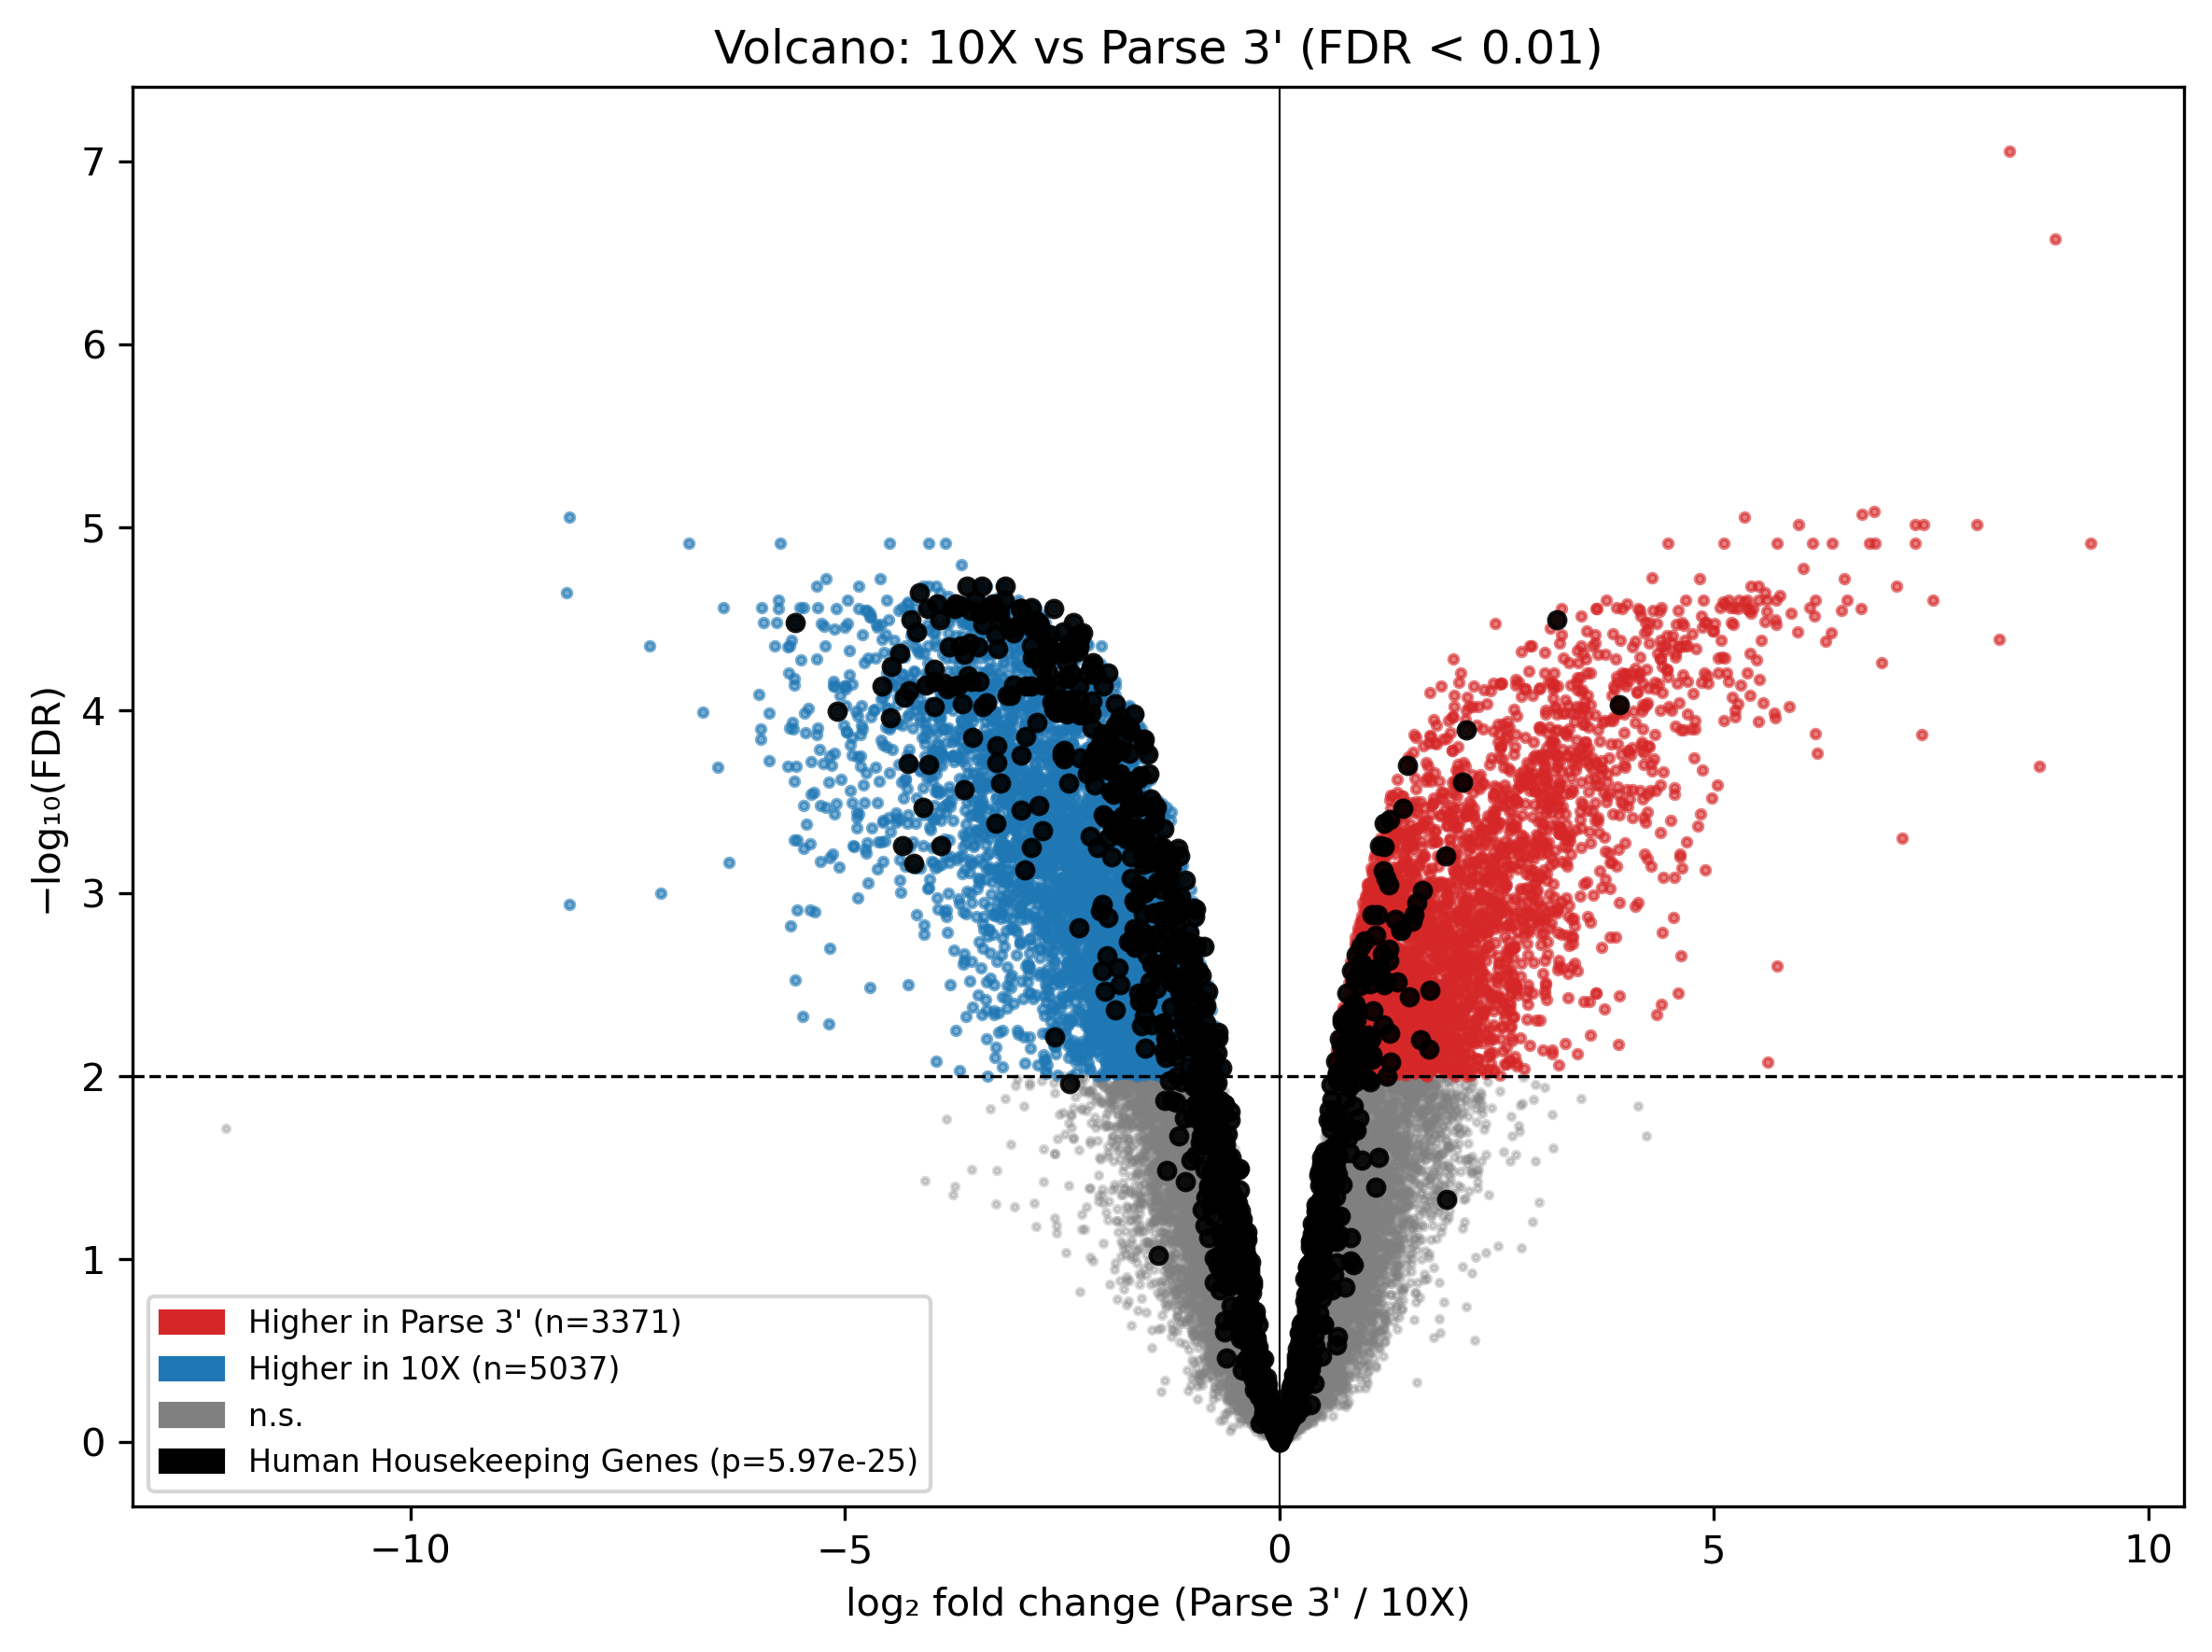

In [10]:
plotting.volcano_plot(results, 
                      COMPARING, 
                      FDR, 
                      label_num = 4,
                      marker_genes_path="/home/mcaskey/10XvParse/Notebooks/important_gene_sets.csv",
                      gene_sets=["Housekeeping"],
                      terms=["Human Housekeeping Genes"],
                      annotate=False)

In [11]:
print(len(results))
print(len(results[results["logFC"] < 0]) / len(results)) 
print(len(results[results["logFC"] > 0]) / len(results))

25006
0.5152363432776134
0.48476365672238664


In [12]:
gene_metrics = plotting.compute_gene_metrics(
    project_dir=PROJECT_DIR,
    index_dir=INDEX_DIR,
    species=SPECIES,
    overwrite=False,
)
results = results.merge(
    gene_metrics[["gene_name", "length_genomic", "gc_genomic",
                  "length_median_tx", "gc_median_tx",
                  "length_exon_union", "gc_exon_union"]],
    on="gene_name", how="left"
)

In [13]:
results = results[~results['gene_name'].str.startswith("RPS") | ~results['gene_name'].str.startswith("RPS")]

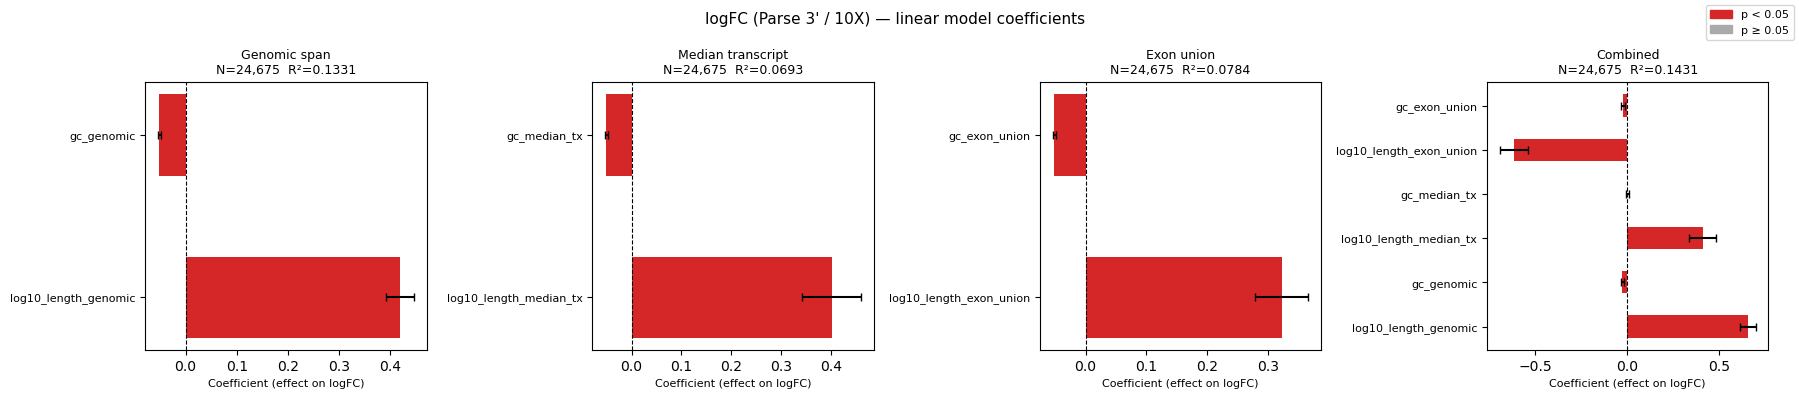

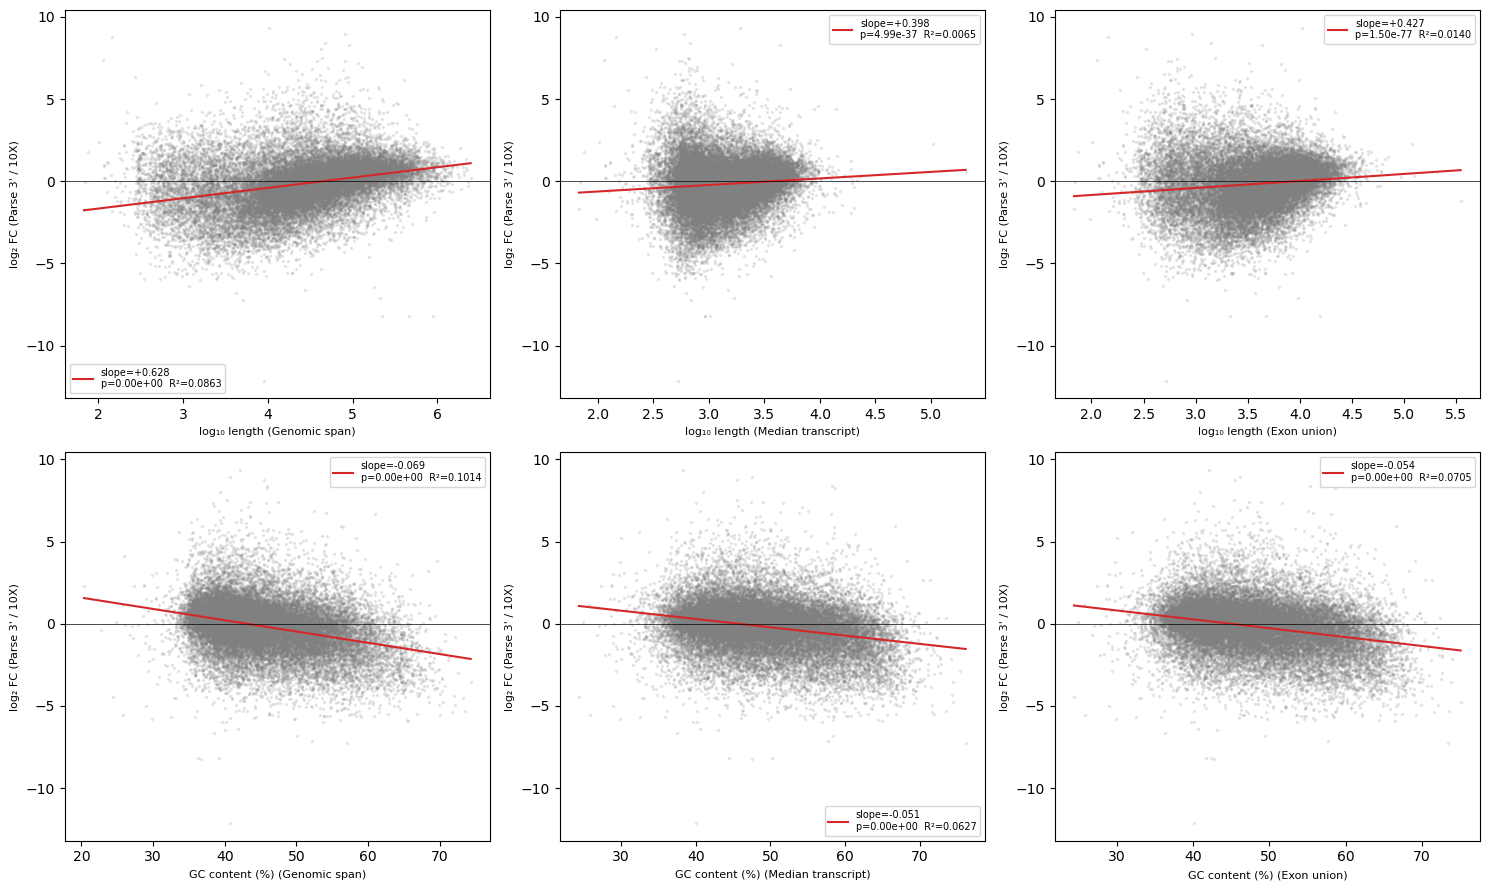

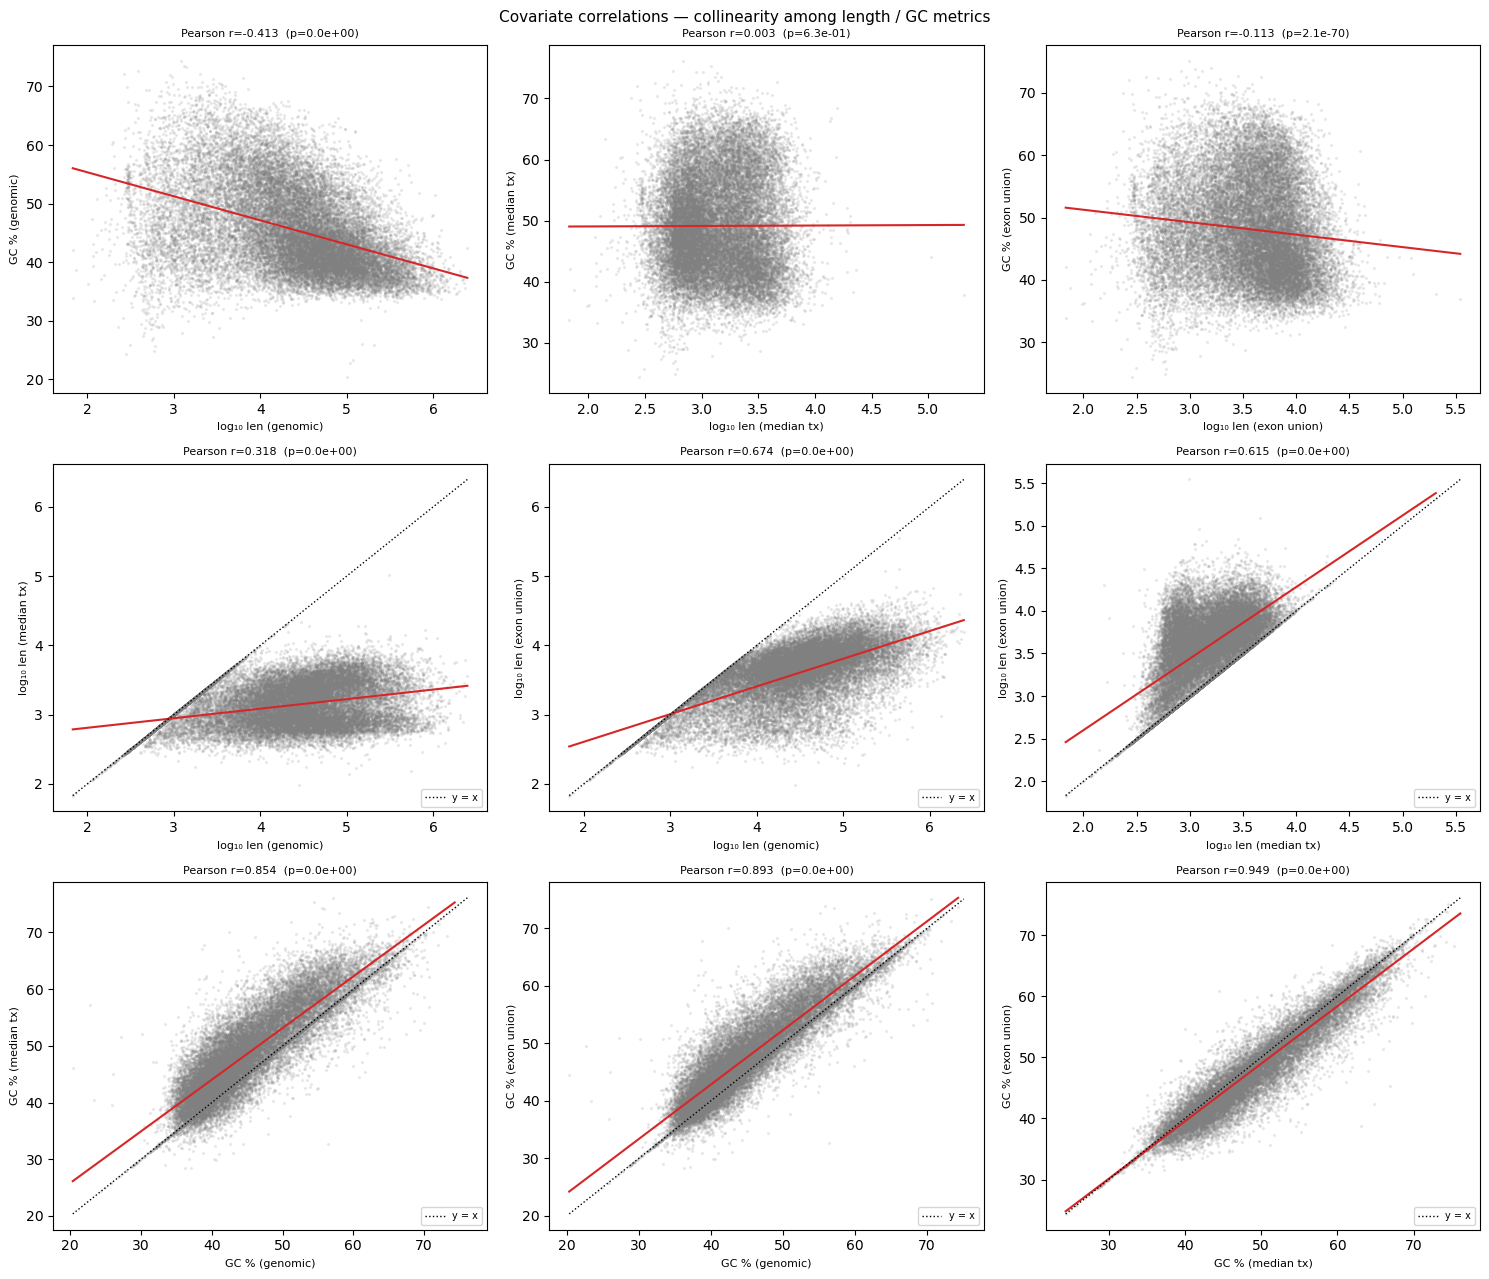


  CONFOUNDING DIAGNOSTICS  (logFC ~ length + GC, three annotation methods)
  N = 24,675

  Method             Covariate                      Uni coef      Uni p   Uni R²   Biv coef      Biv p     VIF
  ────────────────────────────────────────────────────────────────────────────────────────
  Genomic span       log10_len_genomic                0.6281   0.00e+00   0.0863     0.4181  9.07e-195    1.21
  Genomic span       gc_genomic                      -0.0686   0.00e+00   0.1014    -0.0512  5.84e-284    1.21
  Median transcript  log10_len_median_tx              0.3978   4.99e-37   0.0065     0.4017   3.99e-40    1.00
  Median transcript  gc_median_tx                    -0.0505   0.00e+00   0.0627    -0.0506   0.00e+00    1.00
  Exon union         log10_len_exon_union             0.4266   1.50e-77   0.0140     0.3228   9.10e-48    1.01
  Exon union         gc_exon_union                   -0.0540   0.00e+00   0.0705    -0.0519   0.00e+00    1.01


In [14]:
plotting.plot_logfc_lm(results, COMPARING)

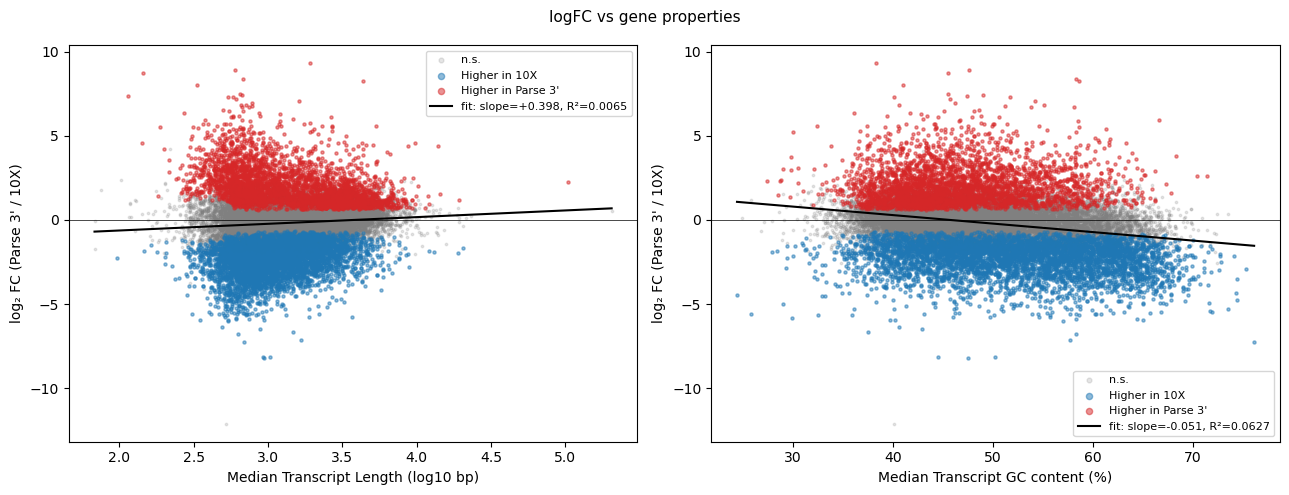

In [15]:
plotting.plot_differential_metrics(results, COMPARING, FDR)

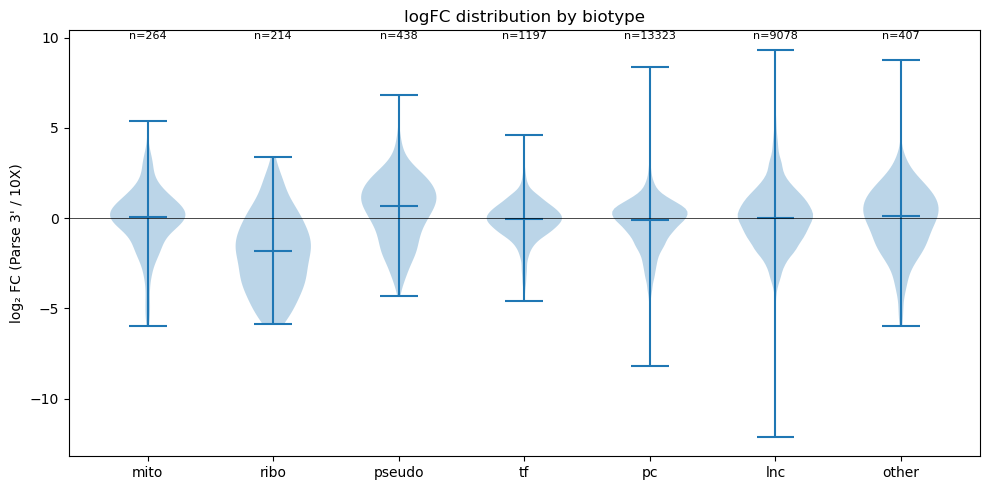

In [16]:
plotting.plot_differential_biotype(results, COMPARING)

In [17]:
sig_10x   = results.loc[(results["FDR"] < 0.01) & (results["logFC"] < 0), "gene_name"].tolist()
sig_parse = results.loc[(results["FDR"] < 0.01) & (results["logFC"] > 0), "gene_name"].tolist()

### GC-bias-corrected functional enrichment (goseq)

GC content predicts differential expression here, so a plain hypergeometric test will report GO terms
that are enriched only because their genes are GC-extreme. `goseq` ([Young et al. 2010](https://doi.org/10.1186/gb-2010-11-2-r14))
fits a probability weighting function `P(gene is DE | GC)` and tests each term with a **Wallenius
non-central hypergeometric** test weighted by that curve, so a term must clear a bar that already
accounts for the bias. The uncorrected test is reported alongside as `P-value (naive)` — that is what
plain Enrichr computes — and each term is classified:

- **GC-robust** — significant before *and* after correction → enrichment is orthogonal to the GC bias.
- **GC-driven** — significant only before correction → a GC artifact.

Two universes are run: all genes from the edgeR analysis, and the same with ribosomal (RP/MRP) and
OXPHOS genes removed (`is_ribo` / `is_oxphos`, the definitions used by `add_cell_metrics`). Excluded
genes are dropped from the *whole* universe, since the weighting function is fit over it.

  10x   : 89 GC-robust, 5 GC-driven (of 94 naively significant); 4963 DE genes, universe 24675 -> 10x_outliers/goseq_enrichment.csv
  polyT : 4 GC-robust, 0 GC-driven (of 4 naively significant); 3330 DE genes, universe 24675 -> polyT_outliers/goseq_enrichment.csv


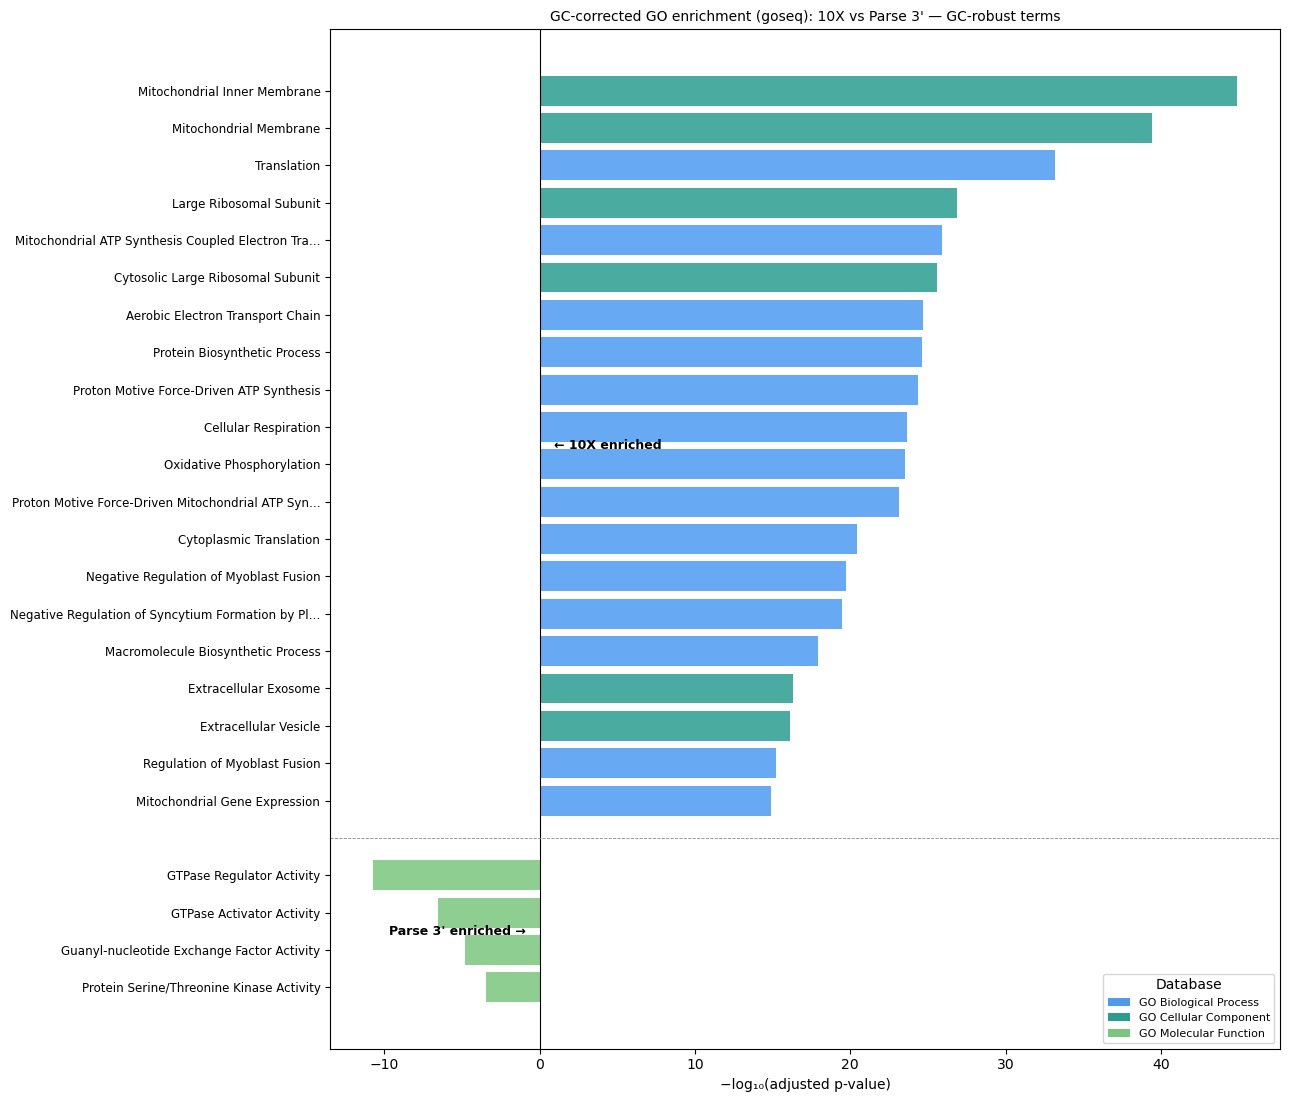

In [18]:
goseq_all = plotting.goseq_enrichment_analysis(
    results=results,
    comparing=COMPARING,
    fdr_thresh=FDR,
    project_dir=PROJECT_DIR,
    species=SPECIES,
    max_terms=20,
)

### Collapsing redundant GO terms

GO output is heavily redundant: nested parent/child terms, and terms that are *semantically*
unrelated but annotated to the same genes, appear as separate findings. In this data the polyT side
returns "Negative Regulation of Myoblast Fusion" at adjP 7e-19 — in PBMCs — and its genes are
**100% ribosomal proteins**; it is the translation signal under a different label.

Terms are therefore grouped by the **overlap coefficient** of their differentially expressed gene
sets, |A∩B| / min(|A|,|B|). Overlap is used rather than Jaccard because GO redundancy is dominated
by *nested* terms, and Jaccard penalises the size gap (a 29-gene child fully inside a 135-gene
parent scores Jaccard 0.21 but overlap 1.00). Groups are maximal cliques of the similarity graph, so
every pair in a group clears the threshold and a term may belong to more than one group — the fuzzy
behaviour of DAVID's multiple-linkage partitioning.

Each group reports its most significant term as representative, plus `core_genes`: the genes shared
by **every** member, i.e. what actually drives the group.

Maximal cliques alone proliferate on a dense graph — several near-identical groups end up covering
the same genes — so seed cliques whose gene content overlaps by more than 50% are merged, following
DAVID's multiple-linkage step. Because merged members need not all overlap pairwise, the strict
intersection is usually empty; `common_genes` (present in ≥50% of a group's terms) is the useful
summary of what a group is built on.

  10x   : 89 terms -> 19 groups (18 term-memberships in >1 group) -> 10x_outliers/goseq_enrichment_clusters.csv
  polyT : 4 terms -> 2 groups (0 term-memberships in >1 group) -> polyT_outliers/goseq_enrichment_clusters.csv


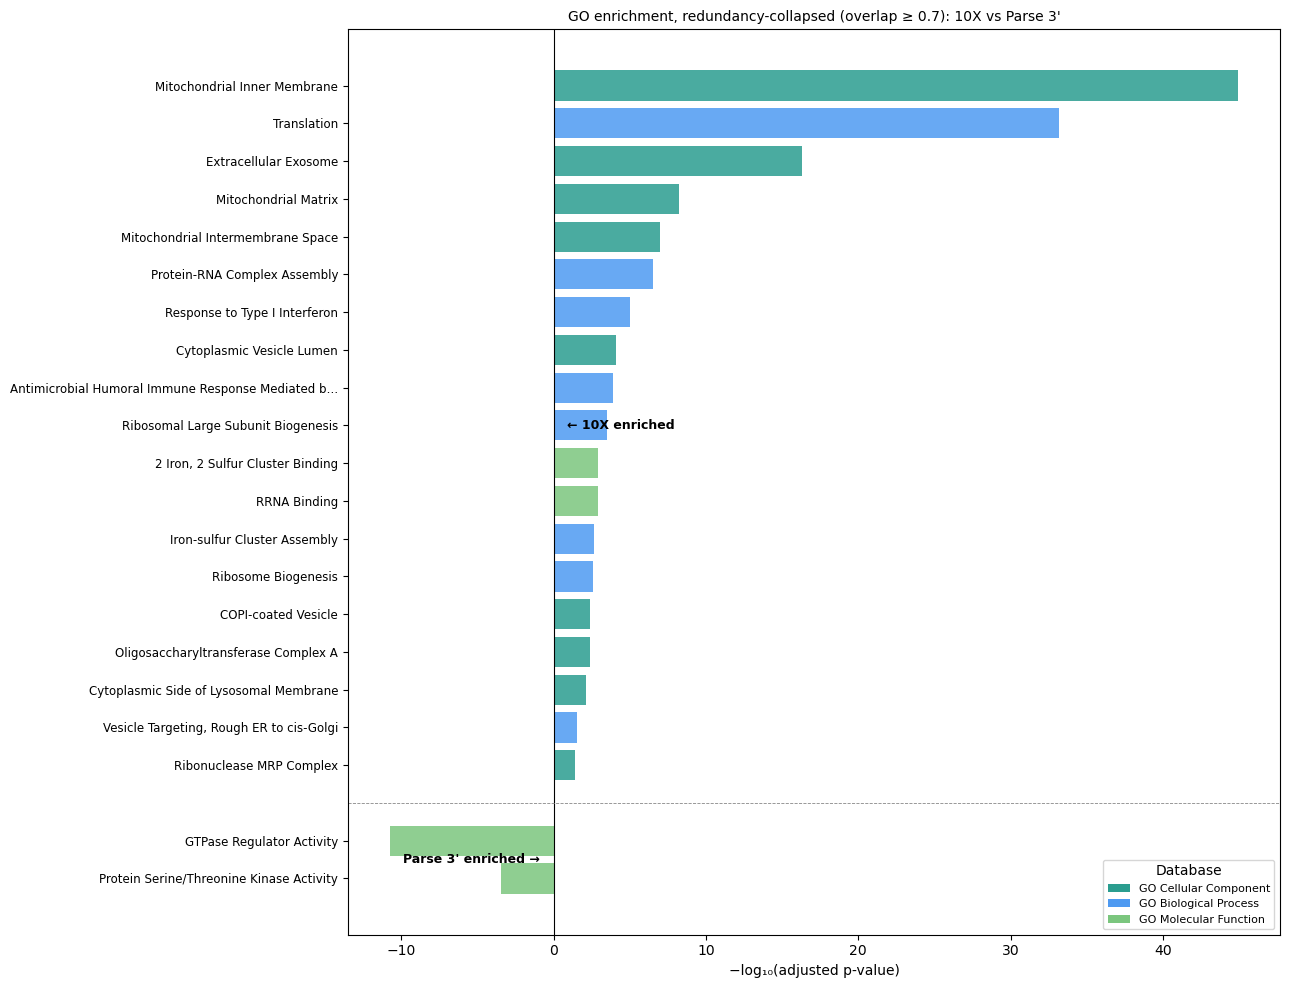

In [ ]:
clusters = plotting.collapse_redundant_terms(goseq_all, COMPARING)

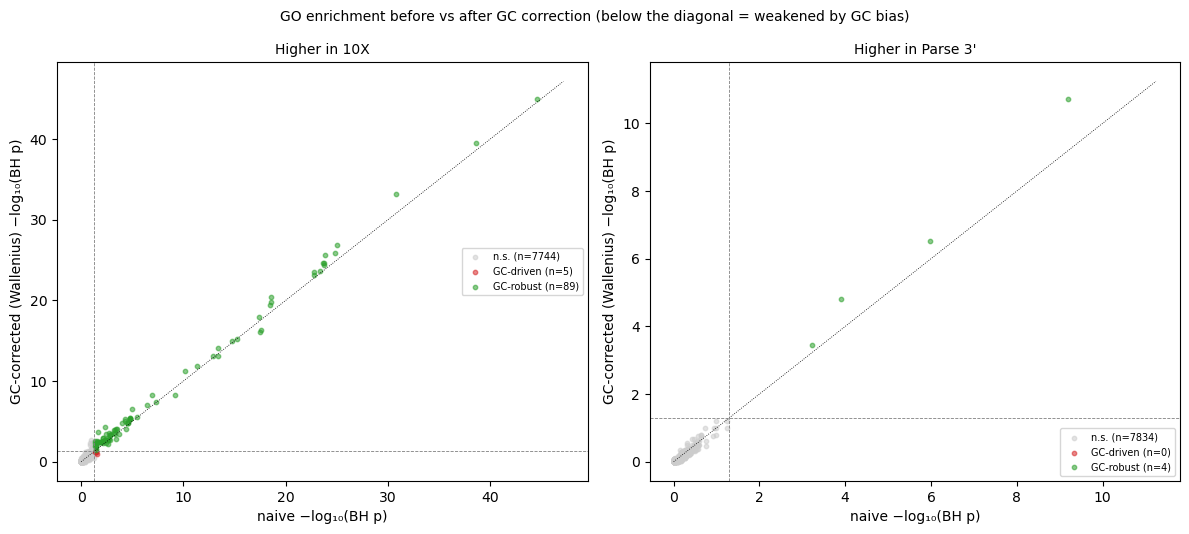

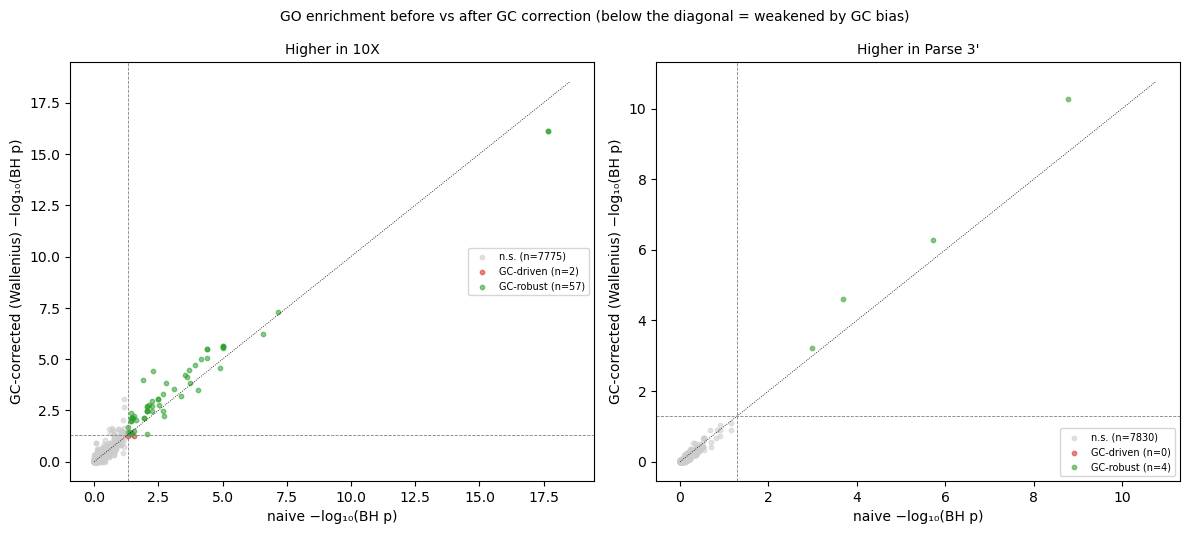

In [ ]:
# Naive vs GC-corrected significance; points below the diagonal were weakened by the GC bias
plotting.plot_gc_correction_scatter(goseq_all, COMPARING)